# CAB Dataset Analysis: Glucose Prediction using kNN

## Overview

This notebook presents a comprehensive analysis of the **Clinical, Anthropometric & Bio-Chemical (CAB) Survey** dataset, focusing on predicting glucose levels using k-Nearest Neighbors (kNN) models.

### Dataset Information

- **Source**: [Kaggle CAB Survey Dataset](https://www.kaggle.com/datasets/rajanand/cab-survey)
- **Objective**: Analyze clinical and anthropometric factors affecting glucose levels
- **Scope**: Investigation of both mean glucose levels and their variability

---

## Methodology

### 1. Data Preprocessing

The dataset includes the following variables:

**Independent variables (X)**:
- **Demographics**: age
- **Anthropometrics**: weight, height, BMI
- **Clinical**: blood pressure (systolic/diastolic), pulse rate
- **Biochemical**: hemoglobin level

**Dependent variable (Y)**:
- Fasting blood glucose (mg/dL)

### 2. kNN Model Configuration

A dual modeling approach is implemented:

1. **Conditional mean model**: Predicts the expected average glucose value
2. **Conditional variance model**: Predicts the variability in glucose levels

**Hyperparameters**:
- Search grid for k: [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
- Separate grids for mean (`grida`) and variance (`gridv`)
- Automatic feature selection based on statistical significance

### 3. Feature Analysis

The process includes:
- Statistical significance testing (p-values)
- Independent feature selection for mean and variance
- Relative importance analysis for each variable

### 4. Visualization

3D plots are generated showing:
- **Weight vs. Pulse Rate vs. Glucose Mean**
- **Weight vs. Pulse Rate vs. Glucose Standard Deviation**

Color mapping: Viridis (improves visual perception of gradients)

---

## Expected Results

1. **Conditional mean**: Identify variables with greatest influence on average glucose levels
2. **Conditional variance**: Determine which factors increase glucose level variability
3. **Patterns**: Visualize non-linear relationships between predictors and target variable

---

## Technical Notes

- **Reproducibility**: Fixed seeds for numpy and random
- **Data type**: float32 for computational efficiency
- **Scalability**: Code prepared for large-scale data analysis

In [1]:
# Import required libraries

import sys
sys.path.append("../..")  # Add path to import knnvs module

# Standard libraries
import math
import random
import logging

# Data analysis libraries
import numpy as np
import pandas as pd

# Machine learning libraries
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split

# knnvs module (custom kNN implementation)
from knnvs import KnnBag, KnnVar, initialize_knn, roc

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure visualization parameters
mpl.rcParams['axes.labelsize'] = 9  # Axis label size

## Data Loading and Preparation

In this section we load the CAB dataset and select the variables for analysis.

**Selected variables**:
- **Independent (X)**: age, weight, height, hemoglobin, systolic/diastolic blood pressure, pulse rate, BMI
- **Dependent (Y)**: fasting blood glucose (mg/dL)

The same variables are used for both female and male participants, enabling unified analysis.

In [2]:
# Set seeds for reproducibility
random.seed(1)
np.random.seed(1)

# Grids for hyperparameter k search
# grida: k values for conditional mean model
# gridv: k values for conditional variance model
grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

# Load dataset
df = pd.read_csv('data/CAB_clean.csv')

# Define dependent and independent variables
out = 'fasting_blood_glucose_mg_dl'  # Target variable (Y)
inp = np.array([
    "age",              # Age
    "weight",           # Weight (kg)
    "height",           # Height (cm)
    "haemoglobin_level", # Hemoglobin level
    "bp_systolic",      # Systolic blood pressure
    "bp_diastolic",     # Diastolic blood pressure
    "pulse_rate",       # Pulse rate (heart rate)
    "bmi"               # Body mass index
])

# Convert to numpy arrays with float32 type
y = df[out].to_numpy().astype('float32')  # Dependent variable
x = df[inp].to_numpy().astype('float32')  # Independent variables

# Commented lines to work with data subset (useful for quick testing)
# x = x[0:10000, :]
# y = y[0:10000]

## kNN Model Initialization and Training

The `initialize_knn` function automatically performs the following steps:

1. **Feature selection**: Identifies the most relevant variables through statistical tests
2. **Cross-validation**: Finds the optimal k value for each model
3. **Training**: Fits both conditional mean and variance models

**Parameters**:
- `x`, `y`: Input and output data
- `grida`, `gridv`: Search grids for k (mean and variance)
- `quantile`: Threshold for feature selection (1 - α = 0.99)

**Returns**:
- `knna0`: kNN model for conditional mean
- `fa0`: Indices of selected features for mean
- `ka0`: Optimal k value for mean
- `pva0`: P-values of features (mean)
- `knnv0`: kNN model for conditional variance
- `fv0`: Indices of selected features for variance
- `kv0`: Optimal k value for variance
- `pvv0`: P-values of features (variance)

In [3]:
# Initialize and train kNN models
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(
    x, y, 
    grida, gridv, 
    quantile=(1 - 0.01)  # 99% confidence level
)

# Create combined model including both mean and variance
knn0 = KnnVar(knna0, knnv0)

# Display selected features
print('Selected features for the conditional mean: {}'.format(inp[fa0]))
print('Selected features for the conditional variance: {}'.format(inp[fv0]))
print(f'\nOptimal k value for mean: {ka0}')
print(f'Optimal k value for variance: {kv0}')

Selected features for the conditional mean: ['age' 'weight' 'haemoglobin_level' 'pulse_rate']
Selected features for the conditional variance: ['weight' 'height' 'haemoglobin_level' 'bp_systolic' 'bp_diastolic'
 'pulse_rate' 'bmi']

Optimal k value for mean: 1000
Optimal k value for variance: 2000


## Generating Predictions on 2D Grid

In this block we generate predictions over a two-dimensional grid to visualize the relationship between:
- **Weight**: Range from 40 to 150 kg
- **Pulse rate**: Range from 55 to 120 beats/min

**Methodology**:
1. Fix all other variables at their mean values
2. For each combination of weight and pulse rate:
   - Predict the **conditional mean** of glucose
   - Predict the **conditional variance** of glucose
3. Save results for 3D visualization

**Note**: Although all possible variable combinations could be analyzed, this example focuses on weight and pulse rate as they are selected features in both models. The code is easily adaptable for other combinations.

In [4]:
# Calculate mean values for all variables (to fix non-analyzed ones)
x_mean = np.mean(x, axis=0)

# Define exploration grids
wgrid = list(np.arange(40, 150, step=0.1))   # Weight: 40-150 kg with step of 0.1
rgrid = list(np.arange(55, 120, step=0.1))   # Pulse rate: 55-120 bpm with step of 0.1

# Lists to store results
weights = []    # Weight values
rates = []      # Pulse rate values
glucoa = []     # Conditional mean predictions
glucov = []     # Conditional variance predictions

# Nested loop to explore all combinations
for w in wgrid:
    for r in rgrid:
        # Create feature vector with variable weight and pulse rate
        # All other variables are fixed at their mean values
        xi = np.array([
            x_mean[0],  # age (mean)
            w,          # weight (variable)
            x_mean[2],  # height (mean)
            x_mean[3],  # haemoglobin_level (mean)
            x_mean[4],  # bp_systolic (mean)
            x_mean[5],  # bp_diastolic (mean)
            r,          # pulse_rate (variable)
            x_mean[7]   # bmi (mean)
        ]).reshape((1, 8)).astype('float32')
        
        # Generate predictions
        glucoa.append(float(knn0.predict_average(xi, k=ka0)))   # Conditional mean
        glucov.append(float(knn0.predict_variance(xi, k=kv0)))  # Conditional variance
        weights.append(w)
        rates.append(r)

# Save results in DataFrame and export to CSV
dict = {
    "weights": weights,
    "rates": rates,
    "glucoa": glucoa,    # Conditional mean of glucose
    "glucov": glucov     # Conditional variance of glucose
}
df2 = pd.DataFrame(dict)
df2.to_csv('cad_1.csv', index=False)

print(f'Grid generated: {len(wgrid)} × {len(rgrid)} = {len(df2)} points')
print(f'Results saved to cad_1.csv')

Grid generated: 1100 × 650 = 715000 points
Results saved to cad_1.csv


## Results Visualization

The following two 3D plots illustrate:

1. **Conditional mean of glucose**: Shows how the expected glucose value varies with weight and pulse rate
2. **Standard deviation of glucose**: Represents the expected variability in glucose levels

These plots allow identification of patterns and non-linear relationships between variables.

### Plot 1: Conditional Mean of Glucose

This 3D plot shows the **conditional mean** of glucose as a function of weight and pulse rate.

**Interpretation**:
- **Weight** shows a pronounced influence on mean glucose levels
- **Pulse rate** has minimal impact on the mean
- An approximately linear trend with weight is observed
- The color gradient (viridis) facilitates identification of regions with high/low glucose levels

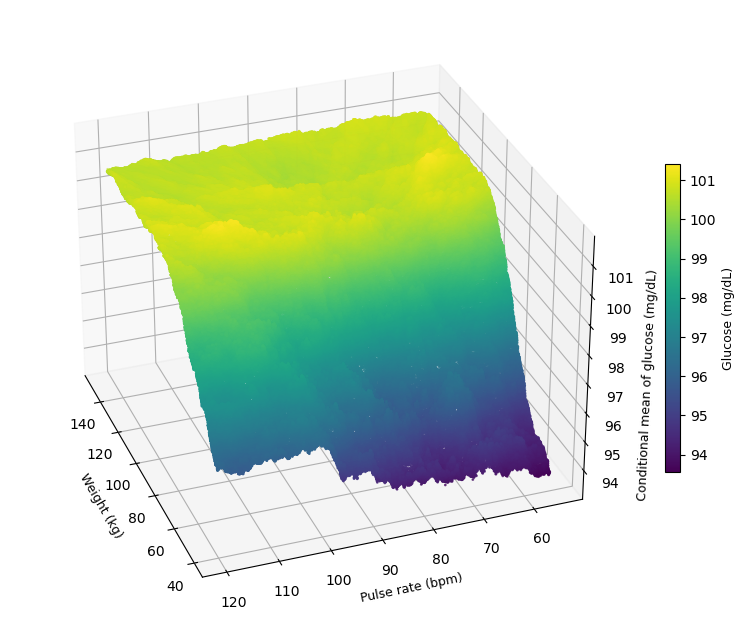

In [5]:
# Create figure for 3D plot of conditional mean
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot with colormap
scatter = ax.scatter(
    df2.weights,      # X-axis: Weight
    df2.rates,        # Y-axis: Pulse rate
    df2.glucoa,       # Z-axis: Conditional mean of glucose
    c=df2.glucoa,     # Color by glucose level
    cmap='viridis',   # Colormap
    s=1               # Point size
)

# Configure labels and visualization
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Pulse rate (bpm)')
ax.set_zlabel('Conditional mean of glucose (mg/dL)')
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Glucose (mg/dL)', shrink=0.5)

# Save figure
plt.savefig('cad_1_avg.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()

### Plot 2: Standard Deviation of Glucose

This 3D plot represents the **conditional standard deviation** of glucose (square root of variance).

**Interpretation**:
- Both **weight** and **pulse rate** proportionally influence variability
- Standard deviation **increases** with both variables
- This suggests that individuals with higher weight and/or pulse rate show more variable glucose levels
- The joint modulation indicates a possible interaction between both factors

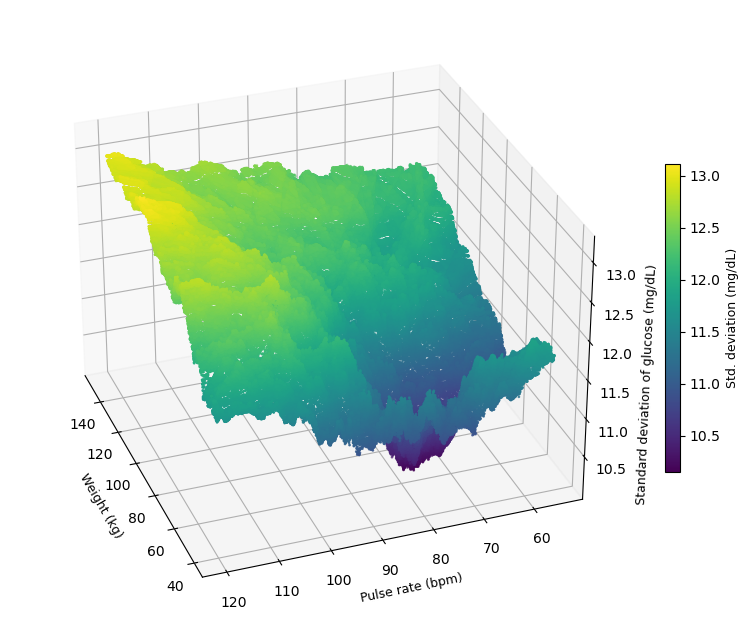

In [6]:
# Create figure for 3D plot of conditional variance
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Calculate standard deviation (square root of variance)
dev = np.sqrt(df2.glucov)

# 3D scatter plot with colormap
scatter = ax.scatter(
    df2.weights,      # X-axis: Weight
    df2.rates,        # Y-axis: Pulse rate
    dev,              # Z-axis: Standard deviation of glucose
    c=dev,            # Color by standard deviation
    cmap='viridis',   # Colormap
    s=1               # Point size
)

# Configure labels and visualization
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Pulse rate (bpm)')
ax.set_zlabel('Standard deviation of glucose (mg/dL)')
ax.grid(True)
ax.set_facecolor('white')  # White background
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Std. deviation (mg/dL)', shrink=0.5)

# Save figure
plt.savefig('cad_1_var.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()